# Praktikum 2 II4012 AI For Business

Anggota Kelompok:


*   Ahmad Evander Ruizhi Xavier (18223064)
*   Sebastian Albern Nugroho (18223074)



# Regression

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
df_train = pd.read_csv('https://drive.google.com/uc?id=1pG8brHNlEr2coKnoTymLiS1UAI83LcMy')
df_test = pd.read_csv('https://drive.google.com/uc?id=1wg_UqDTLWugLAl2pLJFtZClzlsDp-T8E')

## Data Understanding

### Dataset Description

In [ ]:
df_train.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


- Variabel dependen (target):
  - Energy Consumption

- Variabel independen (fitur):
  - Building Type
  - Square Footage
  - Number of Occupants
  - Appliances Used
  - Average Temperature
  - Day of Week

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB


Dataset terdiri dari:
- Variabel numerikal: Square Footage, Number of Occupants, Appliances Used, Average Temperature, Energy Consumption
- Variabel kategorikal: Building Type, Day of Week

### Check Missing Values

In [ ]:
df_train.isnull().sum()

,0
Building Type,0
Square Footage,0
Number of Occupants,0
Appliances Used,0
Average Temperature,0
Day of Week,0
Energy Consumption,0


### Check Duplicates

In [ ]:
df_train.duplicated().sum()

np.int64(0)

### Descriptive Statistics

In [ ]:
df_train.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1000.000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25462.388,48.372000,25.606000,22.611390,4166.252570
std,14294.554,29.061972,14.105166,7.139943,933.313064
min,560.000,1.000000,1.000000,10.050000,1683.950000
25%,13169.750,22.000000,13.000000,16.475000,3509.482500
50%,25477.000,47.000000,26.000000,22.815000,4175.730000
75%,37446.250,73.250000,38.000000,28.850000,4863.850000
max,49997.000,99.000000,49.000000,34.990000,6530.600000


Berdasarkan hasil statistik deskriptif, diperoleh informasi sebagai berikut:

- **Square Footage** memiliki rata-rata sekitar 25,462 dengan nilai minimum 560 dan maksimum 49,997. Hal ini menunjukkan variasi luas bangunan yang cukup besar dalam dataset.

- **Number of Occupants** memiliki rata-rata sekitar 48 orang dengan rentang antara 1 hingga 99. Distribusi ini menunjukkan variasi jumlah penghuni yang cukup merata.

- **Appliances Used** memiliki rata-rata sekitar 25 perangkat dengan nilai minimum 1 dan maksimum 49 yang menunjukkan variasi penggunaan perangkat listrik dalam bangunan.

- **Average Temperature** memiliki rata-rata sekitar 22.61°C dengan rentang dari 10.05°C hingga 34.99°C yang menunjukkan suhu lingkungan bangunan yang masih berada dalam rentang realistis

- **Energy Consumption** sebagai variabel target memiliki rata-rata sekitar 4166 dengan nilai minimum 1683 dan maksimum 6530. Hal ini menunjukkan variasi konsumsi energi yang cukup besar dalam dataset.

Secara keseluruhan, terlihat bahwa nilai mean dan median memiliki jarak yang dekat sehingga sebagian besar variabel memiliki distribusi yang relatif simetris. Namun, terdapat kemungkinan adanya variasi data yang cukup tinggi pada variabel Square Footage dan Energy Consumption yang ditunjukkan oleh nilai standar deviasi yang besar. Selain itu, tidak ditemukan indikasi nilai yang tidak logis (anomali) pada seluruh variabel numerik.

### Data Distribution Analysis

array([[<Axes: title={'center': 'Square Footage'}>,
        <Axes: title={'center': 'Number of Occupants'}>],
       [<Axes: title={'center': 'Appliances Used'}>,
        <Axes: title={'center': 'Average Temperature'}>],
       [<Axes: title={'center': 'Energy Consumption'}>, <Axes: >]],
      dtype=object)

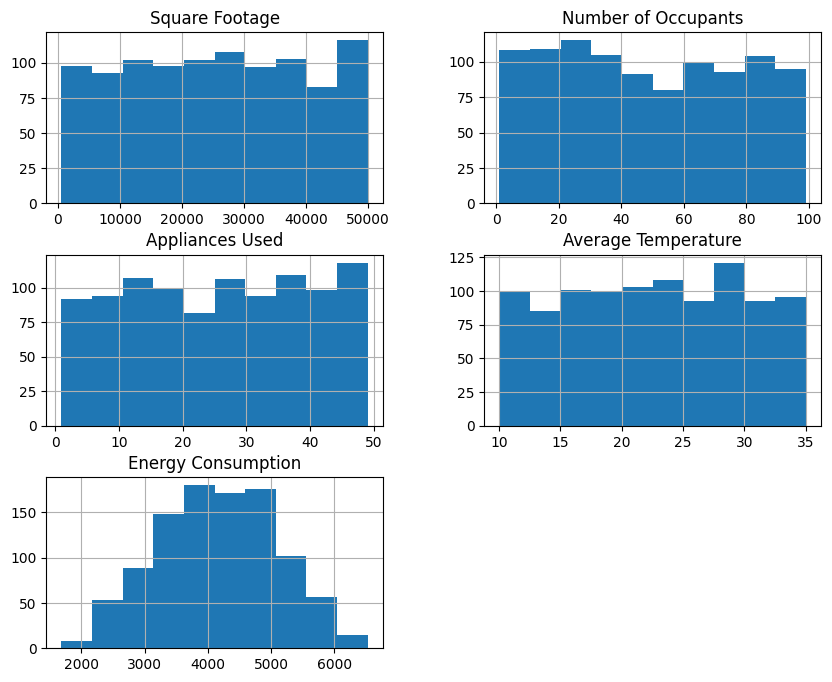

In [ ]:
# Histogram distribusi data keseluruhan variabel numerik
df_train.hist(figsize=(10,8))

Sebagian besar fitur numerik memiliki distribusi yang relatif merata tanpa skew yang signifikan. Variabel Energy Consumption menunjukkan pola mendekati distribusi normal.

### Identify Outliers

<Axes: >

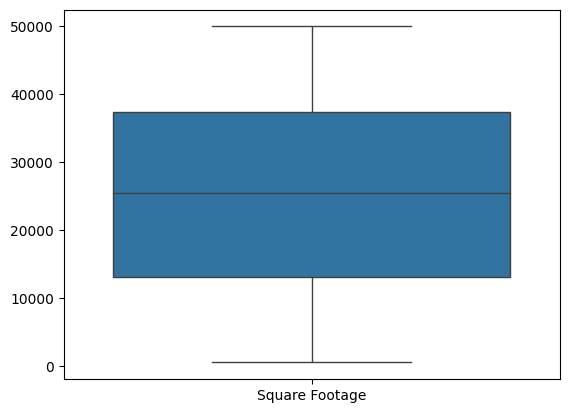

In [ ]:
# Box plot Square Footage
sns.boxplot(data=df_train[['Square Footage']])

<Axes: >

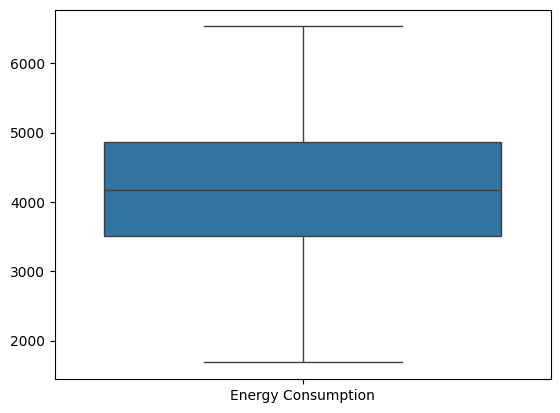

In [ ]:
# Box Plot Energy Consumption
sns.boxplot(data=df_train[['Energy Consumption']])

Identifikasi outlier hanya dilakukan pada variabel Square Footage dan Energy Consumption (variabel lain sudah terlihat jelas tidak memiliki outlier melalui statistik deskriptif sebelumnya). Boxplot di atas tidak menunjukkan adanya outlier pada dua variabel tersebut.

### Trend Analysis and Visualization

In [ ]:
df_train.corr(numeric_only=True)

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
Square Footage,1.000000,0.033379,-0.013478,0.027273,0.774873
Number of Occupants,0.033379,1.000000,0.023646,0.014122,0.354485
Appliances Used,-0.013478,0.023646,1.000000,-0.062870,0.312792
Average Temperature,0.027273,0.014122,-0.062870,1.000000,-0.034487
Energy Consumption,0.774873,0.354485,0.312792,-0.034487,1.000000


Berdasarkan hasil analisis korelasi, Square Footage merupakan fitur yang paling berpengaruh terhadap Energy Consumption sehingga menjadi kandidat fitur utama yang digunakan dalam pemodelan regresi linear. Sementara itu, fitur lain seperti Number of Occupants dan Appliances Used tetap dipertimbangkan karena memberikan kontribusi tambahan terhadap variasi konsumsi energi.

<Axes: xlabel='Square Footage', ylabel='Energy Consumption'>

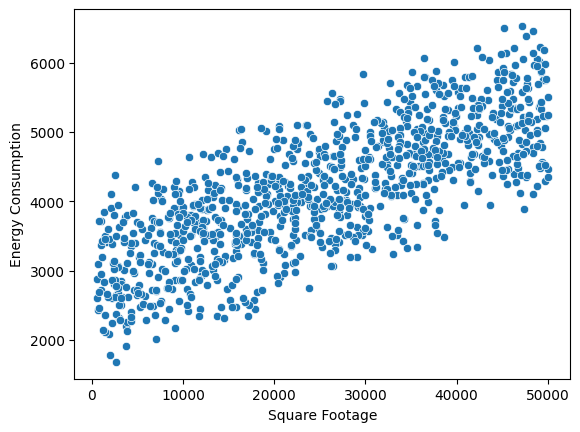

In [ ]:
sns.scatterplot(x='Square Footage', y='Energy Consumption', data=df_train)

Visualisasi menunjukkan kecenderungan peningkatan konsumsi energi seiring bertambahnya luas bangunan.

### Categorical Variable Analysis

In [ ]:
# Building Type
df_train['Building Type'].value_counts()

,count
Building Type,
Residential,347
Commercial,336
Industrial,317


In [ ]:
# Day of Week
df_train['Day of Week'].value_counts()

,count
Day of Week,
Weekday,507
Weekend,493


Berdasarkan distribusi variabel kategorikal, diperoleh informasi sebagai berikut:

- **Building Type** terdiri dari tiga kategori, yaitu Residential (347 data), Commercial (336 data), dan Industrial (317 data). Distribusi ini relatif seimbang antar kategori sehingga tidak terdapat dominasi yang signifikan dari salah satu tipe bangunan.

- **Day of Week** terbagi menjadi Weekday (507 data) dan Weekend (493 data). Distribusi ini juga menunjukkan keseimbangan yang baik antara kedua kategori.

Keseimbangan distribusi pada variabel kategorikal dapat mengurangi potensi bias dalam model dan memastikan bahwa setiap kategori dapat direpresentasikan dengan baik saat training model. Karena kedua variabel bersifat kategorikal, diperlukan proses encoding (seperti one-hot encoding) sebelum digunakan dalam model regresi.

### Feature Selection and Justification

Pemilihan fitur dilakukan berdasarkan hasil analisis korelasi, distribusi data, serta relevansi secara domain terhadap variabel dependen (Energy Consumption).

Pada model linear regression biasa, digunakan satu variabel independen yaitu **Square Footage**. Fitur ini dipilih karena memiliki nilai korelasi tertinggi terhadap Energy Consumption (0.77) yang menunjukkan hubungan linear yang kuat sehingga paling berpengaruh dalam prediksi.

Pada model multiple linear regression, seluruh fitur digunakan karena masing-masing variabel memiliki kontribusi baik secara statistik maupun secara logika terhadap Energy Consumption.

Pada model polynomial regression, fitur utama yaitu Square Footage ditransformasikan ke dalam bentuk polinomial untuk menangkap kemungkinan hubungan non-linear antara variabel independen dan dependen.

## Preprocessing Data

### One-hot Encoding

In [ ]:
# One-hot encoding untuk variabel kategorikal pada data training dan data test
df_train = pd.get_dummies(df_train, drop_first=True)
df_test = pd.get_dummies(df_test, drop_first=True)
df_train.head()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption,Building Type_Industrial,Building Type_Residential,Day of Week_Weekend
0,7063,76,10,29.84,2713.95,False,True,False
1,44372,66,45,16.72,5744.99,False,False,False
2,19255,37,17,14.30,4101.24,True,False,True
3,13265,14,41,32.82,3009.14,False,True,False
4,13375,26,18,11.92,3279.17,False,False,False


### Separate Independent and Dependent Variable

In [ ]:
# Pemisahan fitur dan target pada data training dan data test
X_train = df_train.drop('Energy Consumption', axis=1)
y_train = df_train['Energy Consumption']

X_test = df_test.drop('Energy Consumption', axis=1)
y_test = df_test['Energy Consumption']

### Feature Scaling

In [ ]:
# Feature scaling pada data training dan data test
scaler= StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

## Regresi Linear

### Training

In [ ]:
# Simple Linear Regression (1 fitur)
X_train_lin = df_train[['Square Footage']]
X_test_lin = df_test[['Square Footage']]

lm = LinearRegression()

# Training
lm.fit(X_train_lin, y_train)

# Info
print('Training data:', X_train_lin.shape)
print('Testing data:', X_test_lin.shape)

print('Koefisien:', lm.coef_)
print('Intercept:', lm.intercept_)

Training data: (1000, 1)
Testing data: (100, 1)
Koefisien: [0.0505926]
Intercept: 2878.044046030929


<Axes: xlabel='Square Footage', ylabel='Energy Consumption'>

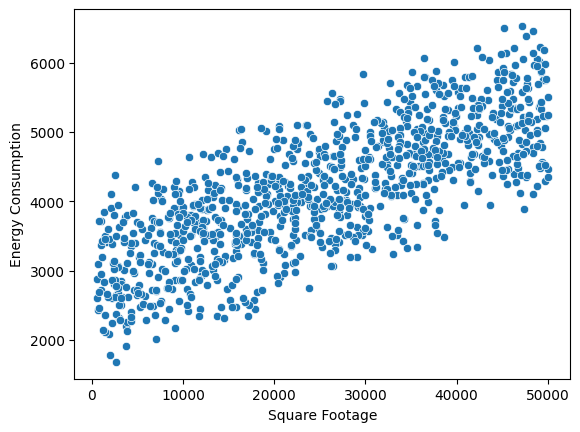

In [ ]:
sns.scatterplot(data=df_train, x="Square Footage", y="Energy Consumption")

(0.0, 6772.932500000001)

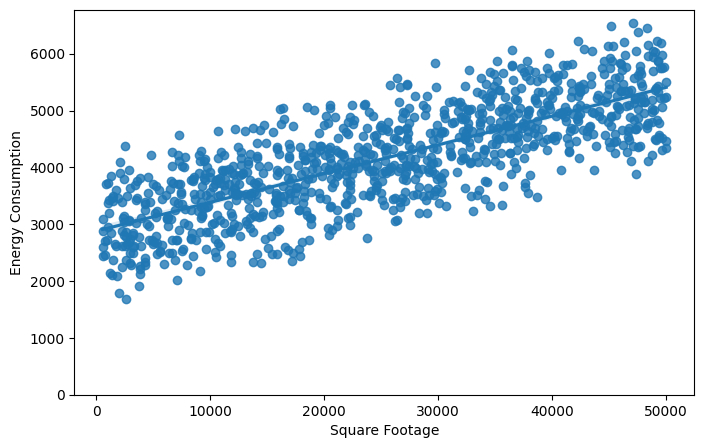

In [ ]:
plt.figure(figsize=(8,5))
sns.regplot(data=df_train, x="Square Footage", y="Energy Consumption")
plt.ylim(0,)

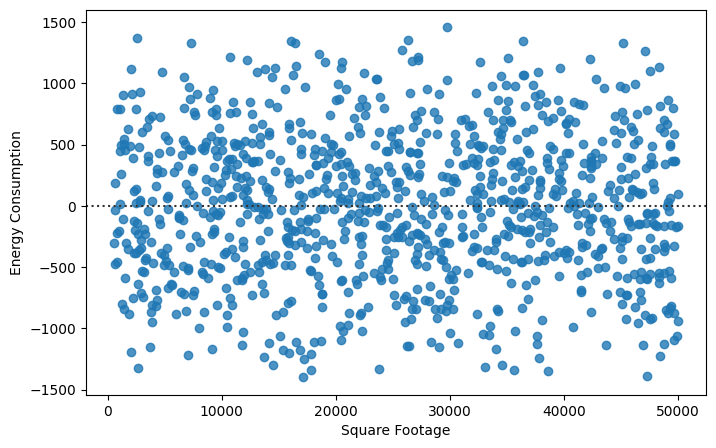

In [ ]:
plt.figure(figsize=(8,5))
sns.residplot(data=df_train, x="Square Footage", y="Energy Consumption")
plt.show()

### Prediction

/tmp/ipykernel_9906/3696618674.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(y_test, hist=False, label="Actual Value")
/tmp/ipykernel_9906/3696618674.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, hist=False, label="Fitted Values", ax=ax1)


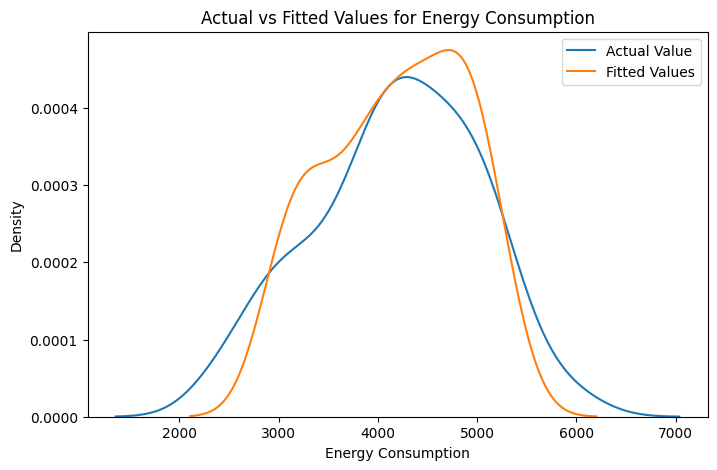

In [ ]:
# Prediksi
y_pred = lm.predict(X_test_lin)

# Plot distribusi
plt.figure(figsize=(8,5))

ax1 = sns.distplot(y_test, hist=False, label="Actual Value")
sns.distplot(y_pred, hist=False, label="Fitted Values", ax=ax1)

plt.title('Actual vs Fitted Values for Energy Consumption')
plt.xlabel('Energy Consumption')
plt.ylabel('Density')

plt.legend()
plt.show()
plt.close()

In [ ]:
print("Mean absolute error: %.2f" % np.mean(np.abs(y_pred - y_test)))
print("Residual sum of squares (MSE): %.2f" % np.mean((y_pred - y_test) ** 2))
print("R2-score: %.2f" % r2_score(y_test, y_pred))

Mean absolute error: 480.42
Residual sum of squares (MSE): 334658.43
R2-score: 0.51


## Multiple Linear Regression

### Training

In [ ]:
feature_names = df_train.drop('Energy Consumption', axis=1).columns

lm_mv_full = LinearRegression()
lm_mv_full.fit(X_train, y_train)

print('Dataset lengkap: ', df_train.shape)
print('Training data: ', X_train.shape)
print('Koefisien: ', lm_mv_full.coef_)
print('Intercept: ', lm_mv_full.intercept_)

Dataset lengkap:  (1000, 8)
Training data:  (1000, 7)
Koefisien:  [ 714.37005936  290.47446069  281.96252355  -35.68219041  232.65394148
 -238.00796777  -24.99793482]
Intercept:  4166.25257


### Prediction

/tmp/ipykernel_9906/905633317.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(y_test, hist=False, color='r', label='Actual Value')
/tmp/ipykernel_9906/905633317.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(test_y_full_, hist=False, color='b', label='Fitted Valu

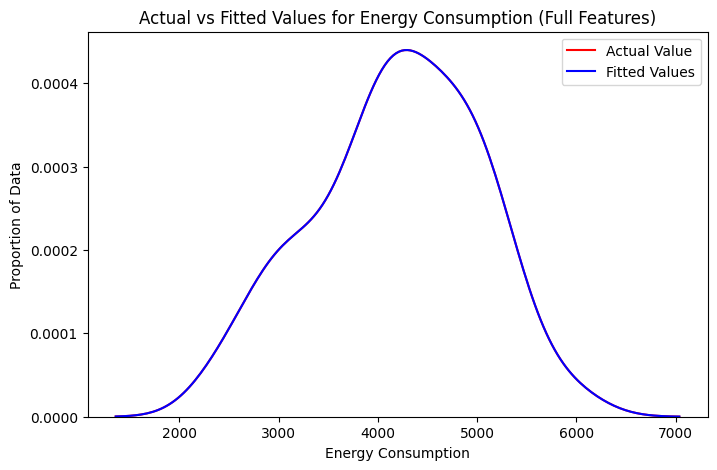

Mean absolute error: 0.01
Residual sum of squares (MSE): 0.00
R2-score: 1.00


In [ ]:
test_x_full = np.asanyarray(X_test)
test_y_full = np.asanyarray(y_test)
test_y_full_ = lm_mv_full.predict(X_test)

plt.figure(figsize=(8, 5))
ax1 = sns.distplot(y_test, hist=False, color='r', label='Actual Value')
sns.distplot(test_y_full_, hist=False, color='b', label='Fitted Values', ax=ax1)
ax1.legend()

plt.title('Actual vs Fitted Values for Energy Consumption (Full Features)')
plt.xlabel('Energy Consumption')
plt.ylabel('Proportion of Data')

plt.show()
plt.close()

print('Mean absolute error: %.2f' % np.mean(np.absolute(test_y_full_ - test_y_full)))
print('Residual sum of squares (MSE): %.2f' % np.mean((test_y_full_ - test_y_full) ** 2))
print('R2-score: %.2f' % r2_score(test_y_full, test_y_full_))

R2 = 1.00 ini menunjukkan indikasi overfitting atau terdapat kesalahan implementasi. Berdasarkan analisis, didapatkan fakta bahwa dataset bersifat sintetis sehingga data terlalu "sempurna".

Ini dibuktikan dengan plot perbandingan dimana plot data aktual dan plot data pelatihan sama.

Oleh karena itu sebagai perbandingan, berikut akan ditambahkan model Multiple Linear Regression berdasarkan 4 fitur numerik utama yang akan menghasilkan R2 score lebih realistis.

In [ ]:
Z = df_train[['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']]
Y = df_train['Energy Consumption']

lm_mv = LinearRegression()
lm_mv.fit(Z, Y)

print('Dataset lengkap: ', df_train.shape)
print('Training data: ', Z.shape)
print('Koefisien: ', lm_mv.coef_)
print('Intercept: ', lm_mv.intercept_)

Dataset lengkap:  (1000, 8)
Training data:  (1000, 4)
Koefisien:  [ 0.05023821 10.33992464 20.71146968 -5.27318328]
Intercept:  1975.8011006113434


/tmp/ipykernel_9906/2533825591.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(test_y, hist=False, color='r', label='Actual Value')
/tmp/ipykernel_9906/2533825591.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(test_y_, hist=False, color='b', label='Fitted Values'

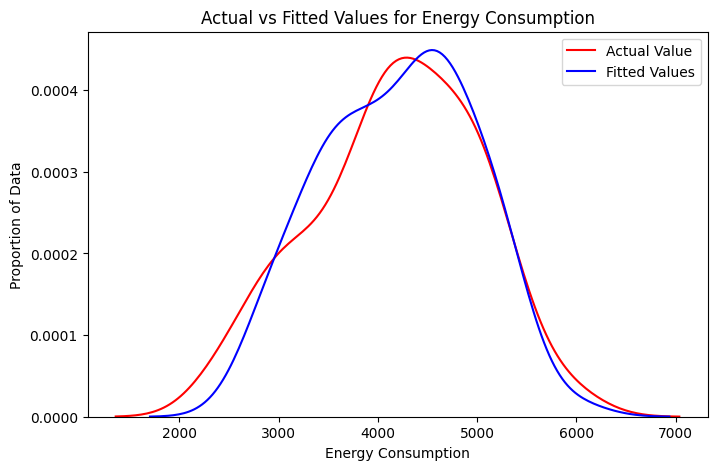

Mean absolute error: 374.23
Residual sum of squares (MSE): 184783.49
R2-score: 0.73


In [ ]:
Z_test = df_test[['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature']]

test_x = np.asanyarray(Z_test)
test_y = np.asanyarray(y_test)
test_y_ = lm_mv.predict(Z_test)

plt.figure(figsize=(8, 5))
ax1 = sns.distplot(test_y, hist=False, color='r', label='Actual Value')
sns.distplot(test_y_, hist=False, color='b', label='Fitted Values', ax=ax1)
ax1.legend()

plt.title('Actual vs Fitted Values for Energy Consumption')
plt.xlabel('Energy Consumption')
plt.ylabel('Proportion of Data')

plt.show()
plt.close()

print('Mean absolute error: %.2f' % np.mean(np.absolute(test_y_ - test_y)))
print('Residual sum of squares (MSE): %.2f' % np.mean((test_y_ - test_y) ** 2))
print('R2-score: %.2f' % r2_score(test_y, test_y_))

Dengan menggunakan 4 fitur numerik, R2 score menjadi 0.67 yang mana lebih realistis dari hasil R2 score sebelumnya.

## Polynomial Regression

### Training

In [ ]:
X_poly = df_train['Square Footage']
Y_poly = df_train['Energy Consumption']
X_test_poly = df_test['Square Footage']
Y_test_poly = df_test['Energy Consumption']

f = np.polyfit(X_poly, Y_poly, 3) # derajat 3
p = np.poly1d(f)
print(p)

            3             2
-9.988e-12 x + 6.421e-07 x + 0.04106 x + 2894


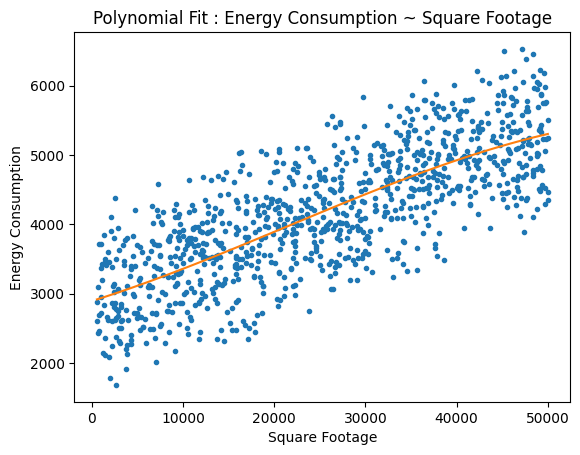

In [ ]:
def PlotPolly(model, independent_variable, dependent_variable, Name):
    x_new = np.linspace(independent_variable.min(), independent_variable.max(), 100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variable, '.', x_new, y_new, '-')
    plt.title('Polynomial Fit : Energy Consumption ~ Square Footage')
    ax = plt.gca()
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Energy Consumption')

    plt.show()
    plt.close()

PlotPolly(p, X_poly, Y_poly, 'Square Footage')

### Prediction

/tmp/ipykernel_9906/2954539368.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(test_y, hist=False, color='r', label='Actual Value')
/tmp/ipykernel_9906/2954539368.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(test_y_, hist=False, color='b', label='Fitted Values'

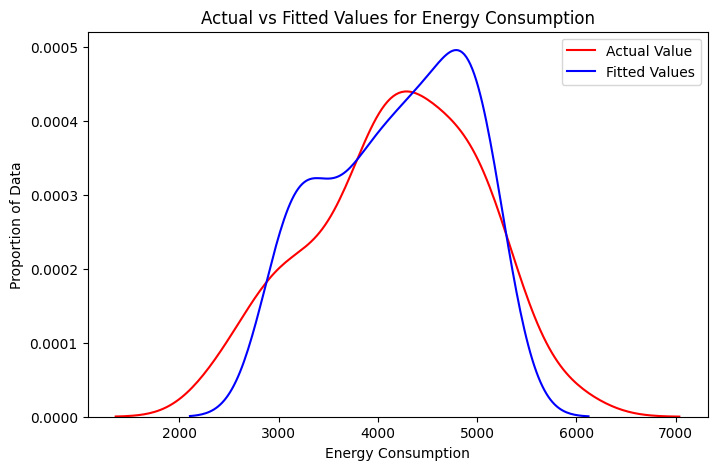

Mean absolute error: 484.82
Residual sum of squares (MSE): 340548.27
R2-score: 0.50


In [ ]:
test_x = np.asanyarray(X_test_poly)
test_y = np.asanyarray(Y_test_poly)
test_y_ = p(X_test_poly)

plt.figure(figsize=(8, 5))

ax1 = sns.distplot(test_y, hist=False, color='r', label='Actual Value')
sns.distplot(test_y_, hist=False, color='b', label='Fitted Values', ax=ax1)
ax1.legend()

plt.title('Actual vs Fitted Values for Energy Consumption')
plt.xlabel('Energy Consumption')
plt.ylabel('Proportion of Data')

plt.show()
plt.close()

print('Mean absolute error: %.2f' % np.mean(np.absolute(test_y_ - test_y)))
print('Residual sum of squares (MSE): %.2f' % np.mean((test_y_ - test_y) ** 2))
print('R2-score: %.2f' % r2_score(test_y, test_y_))

## Perbandingan Antar Model

| Model Regresi                          | MAE    | MSE         | R²   |
|---------------------------------------|--------|-------------|------|
| Regresi Linear                        | 480.42 | 334,658.43  | 0.51 |
| Regresi Linear Berganda               | 0.01   | 0           | 1.00 |
| Regresi Linear Berganda (Fitur Numerik)| 374.23 | 184,783.49  | 0.73 |
| Regresi Polinomial                    | 484.82 | 340,548.27  | 0.50 |